In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

In [ ]:
image_path = "/content/drive/MyDrive/image_compression/torto.png"

image = mpimg.imread(image_path)

# Remove alpha channel if present
if image.shape[2] == 4:
    image = image[:, :, :3]

print("Image Shape:", image.shape)
print("Data Type:", image.dtype)

Image Shape: (855, 690, 3)
Data Type: float32


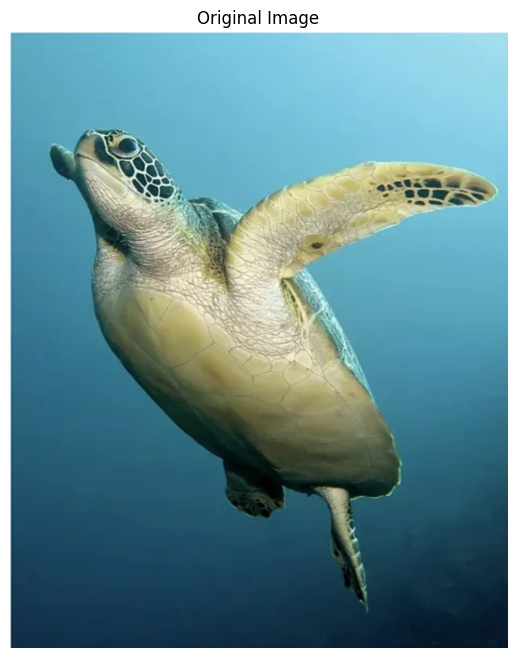

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
height, width, channels = image.shape

print("Height :", height)
print("Width :", width)
print("Channels :", channels)

print("\nFirst Pixel :", image[0,0])

print("\nTotal Pixels :", height*width)

Height : 855
Width : 690
Channels : 3

First Pixel : [0.94509804 0.98039216 0.9882353 ]

Total Pixels : 589950


In [ ]:
K = 16

In [ ]:
def init_centroids(K, image):
    """
    Randomly selects K pixels from the image
    and uses them as initial centroids.
    """

    height, width, channels = image.shape

    centroids = np.empty((K, channels))

    for i in range(K):

        # Random row
        rand_row = random.randint(0, height - 1)

        # Random column
        rand_col = random.randint(0, width - 1)

        # Store RGB value
        centroids[i] = image[rand_row, rand_col]

    return centroids

In [ ]:
centroids = init_centroids(K, image)

print("Centroid Shape:", centroids.shape)

Centroid Shape: (16, 3)


In [ ]:
print(centroids)

[[0.2        0.45882353 0.56862748]
 [0.40392157 0.70980394 0.80392158]
 [0.11764706 0.30980393 0.40784314]
 [0.18039216 0.42352942 0.50980395]
 [0.43529412 0.73333335 0.81960785]
 [0.26274511 0.5411765  0.64313728]
 [0.43529412 0.74117649 0.83529413]
 [0.14509805 0.35294119 0.44705883]
 [0.14901961 0.36470589 0.45882353]
 [0.10588235 0.18431373 0.14509805]
 [0.59607846 0.86274511 0.9254902 ]
 [0.56862748 0.54509807 0.35686275]
 [0.31764707 0.60000002 0.6901961 ]
 [0.02352941 0.15686275 0.15686275]
 [0.24313726 0.50980395 0.6156863 ]
 [0.90196079 0.87450981 0.78039217]]


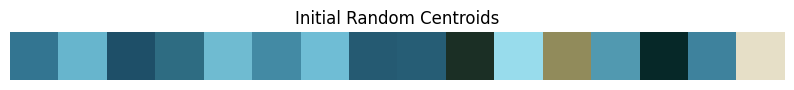

In [ ]:
plt.figure(figsize=(10, 2))

plt.imshow([centroids])

plt.title("Initial Random Centroids")

plt.axis("off")

plt.show()

In [ ]:
def find_closest_centroid(pixel, centroids):
    """
    Returns the index of the closest centroid.
    """
    distances = np.linalg.norm(centroids - pixel, axis=1)
    return np.argmin(distances)

In [ ]:
def assign_clusters(image, centroids):
    """
    Assigns every pixel to its nearest centroid.
    """

    height, width, channels = image.shape

    labels = np.zeros((height, width), dtype=np.int32)

    for i in range(height):
        for j in range(width):
            labels[i, j] = find_closest_centroid(image[i, j], centroids)

    return labels

In [ ]:
labels = assign_clusters(image, centroids)

print(labels.shape)

(855, 690)


In [ ]:
print(labels)

[[15 15 15 ... 15 15 15]
 [15 10 10 ... 15 15 15]
 [15  4 12 ... 10 10 10]
 ...
 [15  3  9 ... 13 13 13]
 [15  3  9 ... 13 13 13]
 [15  3  9 ... 13 13 13]]


In [ ]:
unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} pixels")

Cluster 0: 16698 pixels
Cluster 1: 56478 pixels
Cluster 2: 95707 pixels
Cluster 3: 26305 pixels
Cluster 4: 15918 pixels
Cluster 5: 18045 pixels
Cluster 6: 43479 pixels
Cluster 7: 21731 pixels
Cluster 8: 20272 pixels
Cluster 9: 26668 pixels
Cluster 10: 39871 pixels
Cluster 11: 57818 pixels
Cluster 12: 38388 pixels
Cluster 13: 52054 pixels
Cluster 14: 13200 pixels
Cluster 15: 47318 pixels


In [ ]:
def update_centroids(image, labels, K):
    """
    Computes new centroids by averaging the pixels
    assigned to each cluster.
    """

    height, width, channels = image.shape

    new_centroids = np.zeros((K, channels))

    for k in range(K):

        # Get all pixels belonging to cluster k
        pixels = image[labels == k]

        # Avoid empty clusters
        if len(pixels) > 0:
            new_centroids[k] = np.mean(pixels, axis=0)

    return new_centroids

In [ ]:
new_centroids = update_centroids(image, labels, K)

print(new_centroids.shape)

(16, 3)


In [ ]:
print("Old Centroids:\n")
print(centroids)

print("\nNew Centroids:\n")
print(new_centroids)

Old Centroids:

[[0.2        0.45882353 0.56862748]
 [0.40392157 0.70980394 0.80392158]
 [0.11764706 0.30980393 0.40784314]
 [0.18039216 0.42352942 0.50980395]
 [0.43529412 0.73333335 0.81960785]
 [0.26274511 0.5411765  0.64313728]
 [0.43529412 0.74117649 0.83529413]
 [0.14509805 0.35294119 0.44705883]
 [0.14901961 0.36470589 0.45882353]
 [0.10588235 0.18431373 0.14509805]
 [0.59607846 0.86274511 0.9254902 ]
 [0.56862748 0.54509807 0.35686275]
 [0.31764707 0.60000002 0.6901961 ]
 [0.02352941 0.15686275 0.15686275]
 [0.24313726 0.50980395 0.6156863 ]
 [0.90196079 0.87450981 0.78039217]]

New Centroids:

[[0.20931652 0.46318877 0.55815768]
 [0.39125159 0.68965089 0.77922326]
 [0.11361527 0.27428058 0.35392615]
 [0.19259219 0.42017949 0.4998849 ]
 [0.46230659 0.73164064 0.79296476]
 [0.27570418 0.54728192 0.64612561]
 [0.47371766 0.76971006 0.86385131]
 [0.17345092 0.35646462 0.40816775]
 [0.15965271 0.37758639 0.46302551]
 [0.15908486 0.23666386 0.1996482 ]
 [0.56931973 0.83018351 0.9074

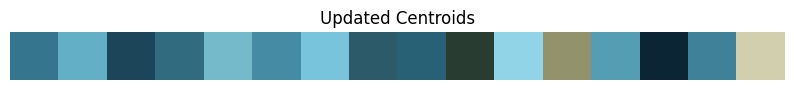

In [ ]:
plt.figure(figsize=(10,2))
plt.imshow([new_centroids])
plt.title("Updated Centroids")
plt.axis("off")
plt.show()

In [ ]:
def kmeans(image, K, max_iters=20):

    # Step 1: Initialize centroids
    centroids = init_centroids(K, image)

    for i in range(max_iters):

        print(f"Iteration {i+1}/{max_iters}")

        # Step 2: Assign pixels to nearest centroid
        labels = assign_clusters(image, centroids)

        # Step 3: Update centroids
        new_centroids = update_centroids(image, labels, K)

        # Step 4: Check convergence
        if np.allclose(centroids, new_centroids):
            print("Converged!")
            break

        centroids = new_centroids

    return centroids, labels

In [ ]:
K = 16

centroids, labels = kmeans(image, K)

Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Iteration 11/20
Iteration 12/20
Iteration 13/20
Iteration 14/20
Iteration 15/20
Iteration 16/20
Iteration 17/20
Iteration 18/20
Iteration 19/20
Iteration 20/20


In [ ]:
print("Centroids Shape:", centroids.shape)
print("Labels Shape:", labels.shape)

Centroids Shape: (16, 3)
Labels Shape: (855, 690)


In [ ]:
def compress_image(labels, centroids):
    """
    Replace every pixel with its centroid color.
    """

    compressed_image = centroids[labels]

    return compressed_image

In [ ]:
compressed_image = compress_image(labels, centroids)

print(compressed_image.shape)

(855, 690, 3)


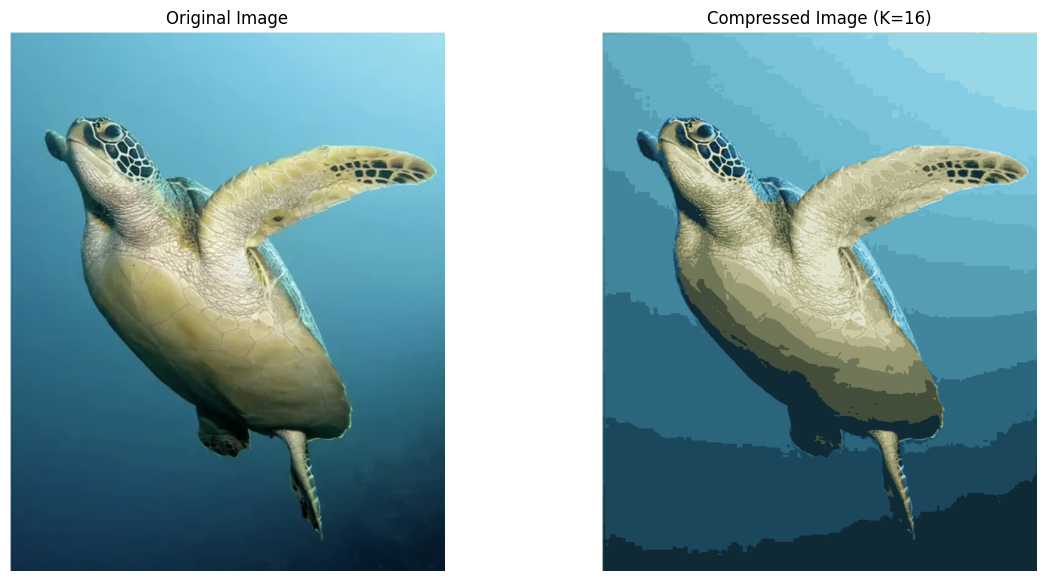

In [ ]:
plt.figure(figsize=(14,7))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(compressed_image)
plt.title(f"Compressed Image (K={K})")
plt.axis("off")

plt.show()

In [ ]:
plt.imsave("compressed_image.png", compressed_image)

Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Converged!
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Iteration 11/20
Iteration 12/20
Iteration 13/20
Iteration 14/20
Iteration 15/20
Iteration 16/20
Iteration 17/20
Iteration 18/20
Iteration 19/20
Iteration 20/20
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Iteration 11/20
Iteration 12/20
Iteration 13/20
Iteration 14/20
Iteration 15/20
Iteration 16/20
Iteration 17/20
Iteration 18/20
Iteration 19/20
Iteration 20/20
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Iteration 11/20
Iteration 12/20
Iteration 13/20
Iteration 14/20
I

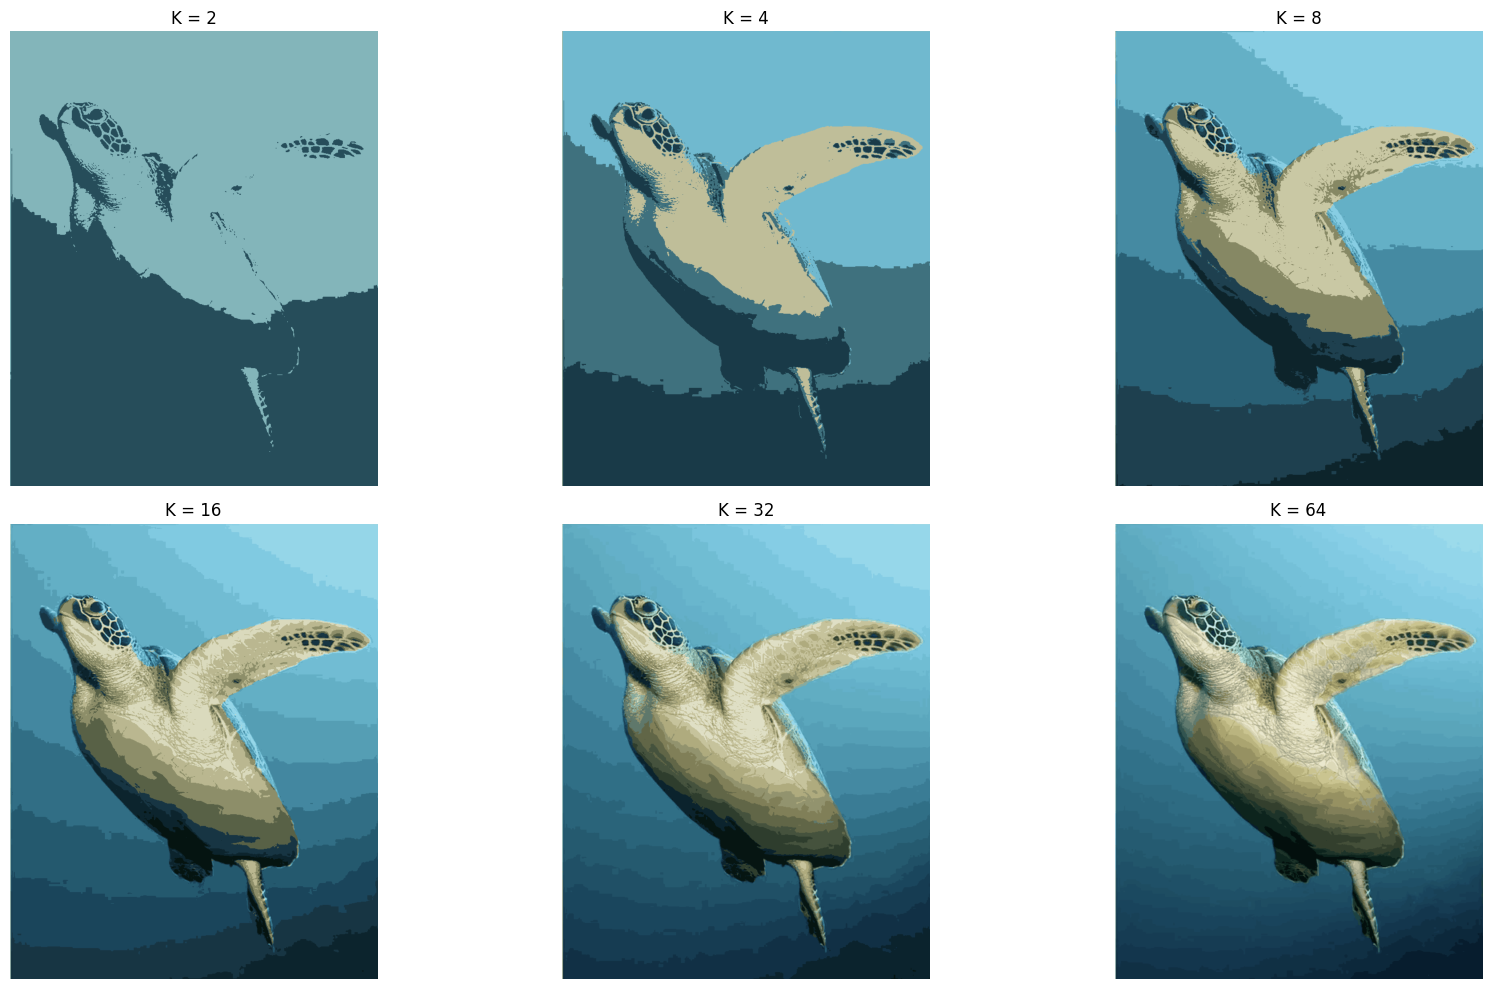

In [44]:
k_values = [2, 4, 8, 16, 32, 64]

plt.figure(figsize=(18,10))

for i, k in enumerate(k_values):

    centroids, labels = kmeans(image, k)

    compressed = compress_image(labels, centroids)

    plt.subplot(2,3,i+1)
    plt.imshow(compressed)
    plt.title(f"K = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()